In [316]:
import numpy as np
import matplotlib.pyplot as plt
import os

# check out the data

In [317]:
!ls data/

current_foreground_noise_model.dat  foreground_noise_model.dat
current_instrument_noise_model.dat  full_noise_model.dat
current_sgwb_noise_model.dat        instrument_noise_model.dat
dft_data.dat                        power_data.dat
dwt_data.dat                        power_noise_reconstruction.dat
final_foreground_noise_model.dat    scaleogram_data.dat
final_full_noise_model.dat          sgwb_noise_model.dat
final_instrument_noise_model.dat    whitened_data.dat
final_sgwb_noise_model.dat


In [373]:
scaleogram_data = np.loadtxt('data/scaleogram_data.dat')
full_noise = np.loadtxt('data/full_noise_model.dat')

In [365]:
scaleogram_data = np.loadtxt('data-bug/scaleogram_data.dat')
full_noise = np.loadtxt('data-bug/full_noise_model.dat')

In [176]:
# cols are t, f, |X|^2, |Y|^2, |Z|^2

In [374]:
scaleogram_data.shape

(16200, 5)

In [375]:
# cols are t, f, CXX, CYY, CZZ, CXY, CXZ, CYZ

In [376]:
full_noise.shape[0]//4050

4

In [377]:
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
from matplotlib import colors
%matplotlib inline
def wavelet_specgram(t, f, pz, Nt = 512, clip = 0, lognorm=False, cmap='bwr'):
    Nf = t.shape[0] // Nt
    if t.shape[0] != Nt*Nf or f.shape[0] != Nt*Nf:
        print("Nt or Nf is wrong")
    z = pz.copy()
    if lognorm:
        z = np.ma.masked_less_equal(z.astype(float), 0)
        lo, hi = np.nanpercentile(z.compressed(), [clip, 100-clip])
        norm = colors.AsinhNorm(vmin=lo, vmax = hi, clip=True)
    else:
        lo, hi = np.nanpercentile(z, [clip, 100-clip])
        norm = colors.Normalize(vmin=lo, vmax = hi, clip=True)
    #plt.imshow(z.reshape((Nf,Nt)),cmap=cmap,norm=norm,aspect=9/16*Nt/Nf,interpolation='none')
    fig, ax = plt.subplots()
    m = ax.pcolormesh(t[::Nf], f[:Nf], z.reshape((Nt,Nf)).T, cmap=cmap, norm=norm, shading='auto',snap=True, rasterized=True)
    fig.colorbar(m,ax=ax)
    plt.xlabel('t')
    plt.ylabel('f')
    plt.show()
    

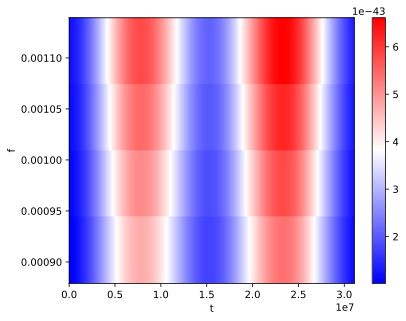

In [378]:
wavelet_specgram(full_noise[:,0], full_noise[:,1], full_noise[:,2], Nt=4050)

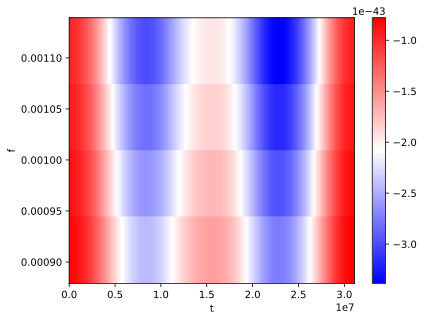

In [379]:
wavelet_specgram(full_noise[:,0], full_noise[:,1], full_noise[:,7], Nt=4050)

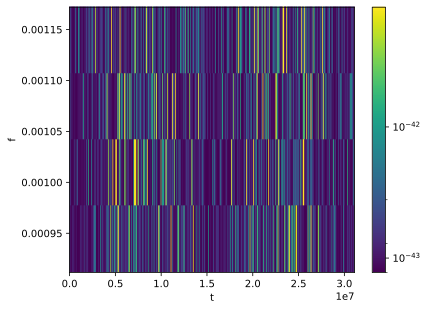

In [380]:
wavelet_specgram(scaleogram_data[:,0], scaleogram_data[:,1], scaleogram_data[:,2], Nt=4050, clip=3, lognorm=True, cmap='viridis')

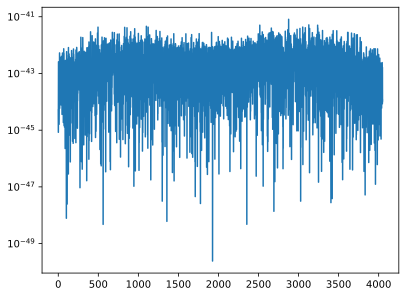

In [381]:
plt.semilogy(scaleogram_data[::4,4])

# check out the chains

In [387]:
sgwb = np.loadtxt('chains-bug/sgwb_chain.dat')#, max_rows=900)

In [382]:
sgwb = np.loadtxt('chains/sgwb_chain.dat')#, max_rows=900)

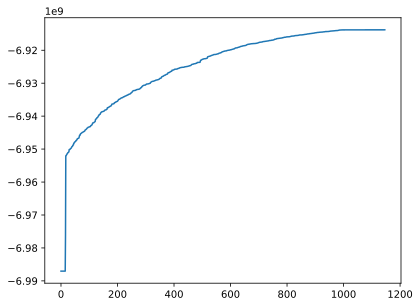

In [388]:
plt.plot(sgwb[:,1])

In [384]:
from corner import corner

In [389]:
burn = 200
sgwb_chain = np.array(
    [
        sgwb[burn:,2], # logA
        sgwb[burn:,3], # alpha
    ]).T
sgwb_labels = [r'$\log A$', r'$\alpha$']

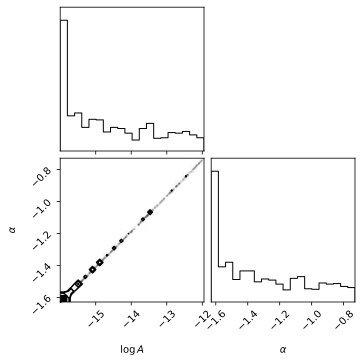

In [390]:
corner(sgwb_chain, labels = sgwb_labels)
plt.show()